# 05 · Does compression speed up classification? And can PCA flag unusual inputs?

**Part E (exercise 9):** train a classifier on the 784 raw pixels and on the 154 PCA features; compare training time, prediction time and accuracy. The book uses a Random Forest. The same comparison is run for Softmax Regression and for an RBF-kernel SVM, the classifier p. 226 says PCA can "speed up tremendously". The SVM pair is the one deployed. The PCA is fitted on all 60,000 training images (it needs no labels); accuracies come with 95% confidence intervals computed as in the book's Ch. 2, and raw vs PCA with a *paired* interval on the per-image difference.

**Part F:** a digit that PCA rebuilds badly is unlike the training digits. Reconstruction error (Ch. 8, p. 226) combined with the book's 4% percentile threshold (Ch. 9, p. 266) gives an "unusual input" flag.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from dimred_mlops.config import load_config
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 20)
CFG = load_config(ROOT / "configs/full_flow_config.yaml")
SEED = CFG["seed"]
# figures are drawn into a temporary folder: reports/figures belongs to the pipeline run
import tempfile
FIG = Path(tempfile.mkdtemp(prefix="nb-figures-"))

In [2]:
from dimred_mlops.data import load_mnist_split
split = load_mnist_split(ROOT / "data")     # first 60,000 = train, last 10,000 = test
X_train, y_train, X_test, y_test = split.X_train, split.y_train, split.X_test, split.y_test
split.sizes

{'n_train': 60000, 'n_test': 10000, 'n_features': 784}

In [3]:
from dimred_mlops.classification import run_part_e
e = run_part_e(split, CFG["part_e"], SEED)
e.table.round(4).assign(svm_gamma=e.table.svm_gamma.map(lambda g: f"{g:.2e}" if g == g else ""))

,classifier,kind,features,n_features,n_train,fit_seconds,fit_runs,predict_seconds_10k,test_accuracy,accuracy_ci_low,accuracy_ci_high,svm_gamma,model_MB
0,Softmax Regression,softmax,raw,784,60000,34.5833,3,0.0082,0.9264,0.9213,0.9315,,0.0474
1,Softmax Regression,softmax,pca,154,60000,4.3352,3,0.0318,0.9232,0.9180,0.9284,,0.5244
2,Random Forest,random_forest,raw,784,60000,28.3042,3,0.2710,0.9705,0.9672,0.9738,,146.0633
3,Random Forest,random_forest,pca,154,60000,71.0213,1,0.2519,0.9495,0.9452,0.9538,,212.7835
4,SVM (RBF kernel),svm,raw,784,20000,23.0106,3,25.2195,0.9701,0.9668,0.9734,2.06e-07,39.3424
5,SVM (RBF kernel),svm,pca,154,20000,8.9806,3,9.6750,0.9748,0.9717,0.9779,3.06e-07,8.6332
6,SVM (RBF kernel),svm,pca_same_gamma,154,20000,7.7473,3,8.8776,0.9713,0.9680,0.9746,2.06e-07,8.1831


In [4]:
pd.Series(e.metrics).round(3)

softmax_raw_accuracy                        0.926
softmax_pca_accuracy                        0.923
softmax_fit_speedup                         7.977
softmax_predict_speedup                     0.256
softmax_accuracy_change_pp                 -0.320
softmax_accuracy_change_ci_low_pp          -0.611
softmax_accuracy_change_ci_high_pp         -0.029
random_forest_raw_accuracy                  0.970
random_forest_pca_accuracy                  0.950
random_forest_fit_speedup                   0.399
random_forest_predict_speedup               1.076
random_forest_accuracy_change_pp           -2.100
random_forest_accuracy_change_ci_low_pp    -2.464
random_forest_accuracy_change_ci_high_pp   -1.736
svm_raw_accuracy                            0.970
svm_pca_accuracy                            0.975
svm_fit_speedup                             2.562
svm_predict_speedup                         2.607
svm_accuracy_change_pp                      0.470
svm_accuracy_change_ci_low_pp               0.310


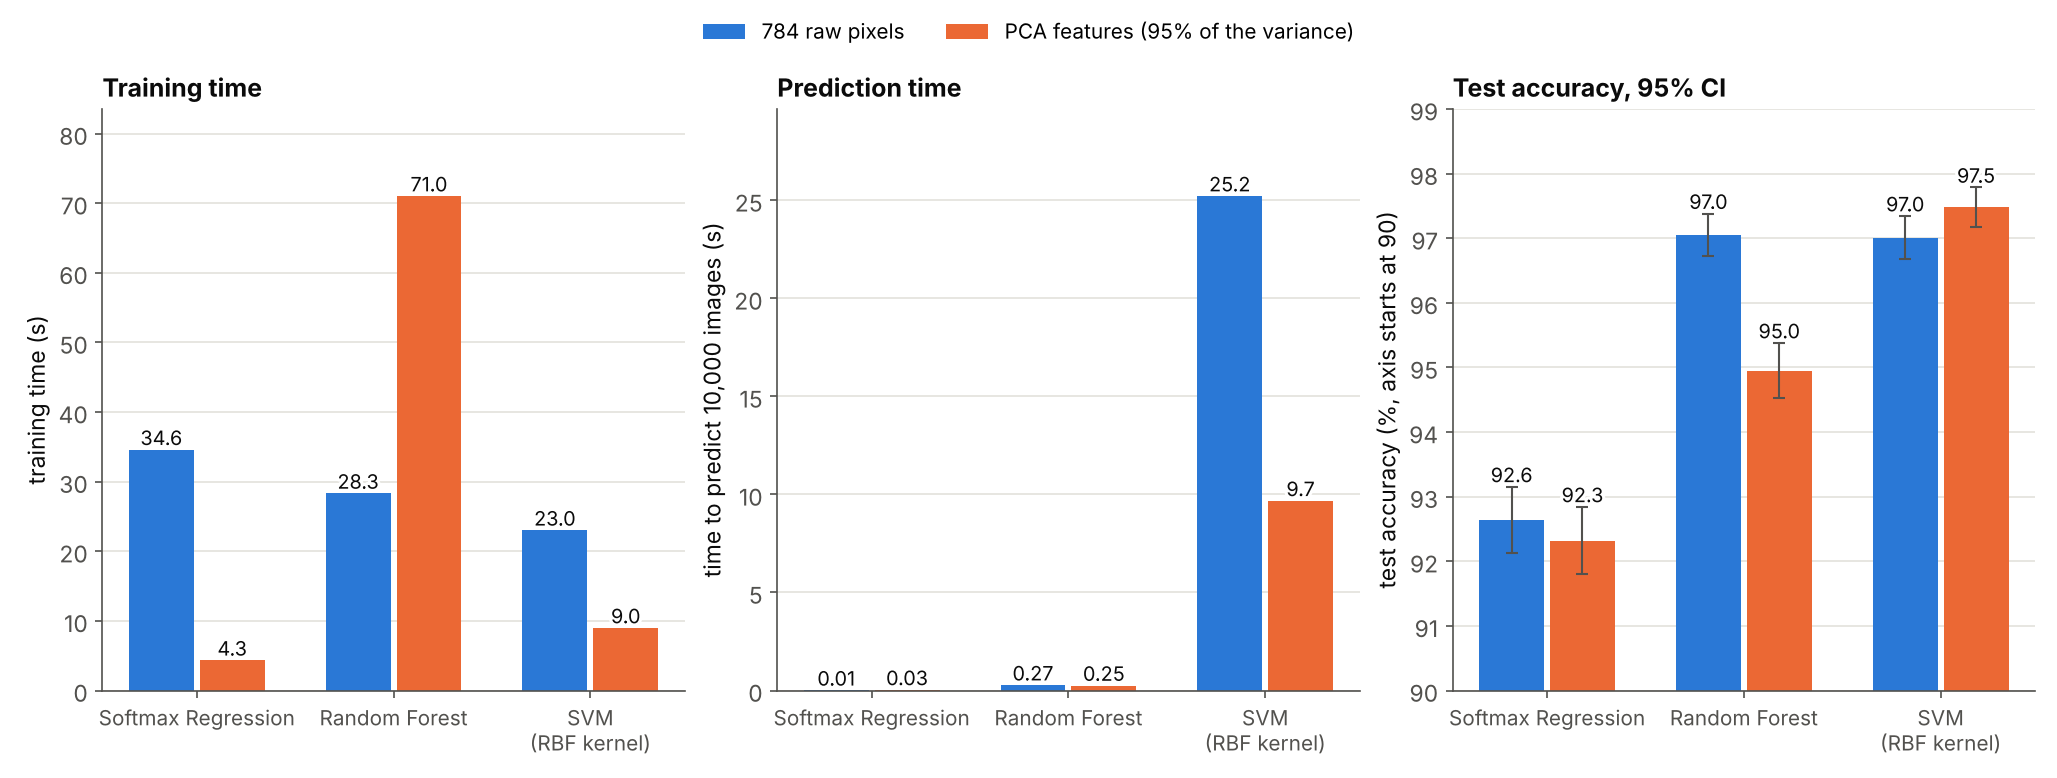

In [5]:
from dimred_mlops import plots
plots.classification(e.table, FIG / "e_classification.png")
display(Image(str(FIG / "e_classification.png"), width=950))

## The unusual-input detector
The threshold is the 96th percentile of reconstruction errors on 10,000 held-out training images, so about 4% of normal digits are flagged.

In [6]:
from dimred_mlops.detector import run_part_f, error_rate_by_flag
f = run_part_f(split, CFG["part_f"], SEED)
f.corruption_table.round(2)

,input,flagged_pct,median_error
0,clean test digits,3.34,198.41
1,noise,100.00,10908.25
2,inverted,100.00,26458.54
3,shuffled,100.00,5297.32
4,rotated,12.73,246.49
5,mirrored,17.20,268.68
6,shifted,90.24,1119.02
7,gaussian,100.00,2230.65
8,dimmed,0.00,18.22


In [7]:
f.threshold_sweep.round(2)

,flag_rate_pct,threshold,clean_false_alarm_pct,detect_noise_pct,detect_inverted_pct,detect_shuffled_pct,detect_rotated_pct,detect_mirrored_pct,detect_shifted_pct,detect_gaussian_pct,detect_dimmed_pct,mean_detection_pct
0,1,542.65,0.85,100.0,100.0,100.0,4.95,7.31,82.93,100.0,0.0,61.90
1,2,488.79,1.68,100.0,100.0,100.0,7.79,10.85,86.60,100.0,0.0,63.16
2,4,426.96,3.34,100.0,100.0,100.0,12.73,17.20,90.24,100.0,0.0,65.02
3,6,387.68,5.37,100.0,100.0,100.0,17.45,22.40,92.33,100.0,0.0,66.52
4,8,365.29,6.89,100.0,100.0,100.0,20.87,26.32,93.56,100.0,0.0,67.59
5,10,346.51,8.46,100.0,100.0,100.0,24.43,29.88,94.46,100.0,0.0,68.60


In [8]:
f.variance_sweep.round(3)

,variance,n_components,clean_false_alarm_pct,mean_detection_pct,roc_auc
0,0.80,44,2.84,67.024,0.819
1,0.90,87,3.12,66.314,0.806
2,0.95,154,3.34,65.021,0.791
3,0.99,331,3.67,65.489,0.786


In [9]:
error_rate_by_flag(e.models["pca"], f.detector, X_test, y_test)

{'n_flagged_clean': 334,
 'error_rate_flagged_pct': 5.9880239520958085,
 'error_rate_unflagged_pct': 2.400165528657149,
 'n_errors_flagged': 20,
 'n_errors_total': 252}

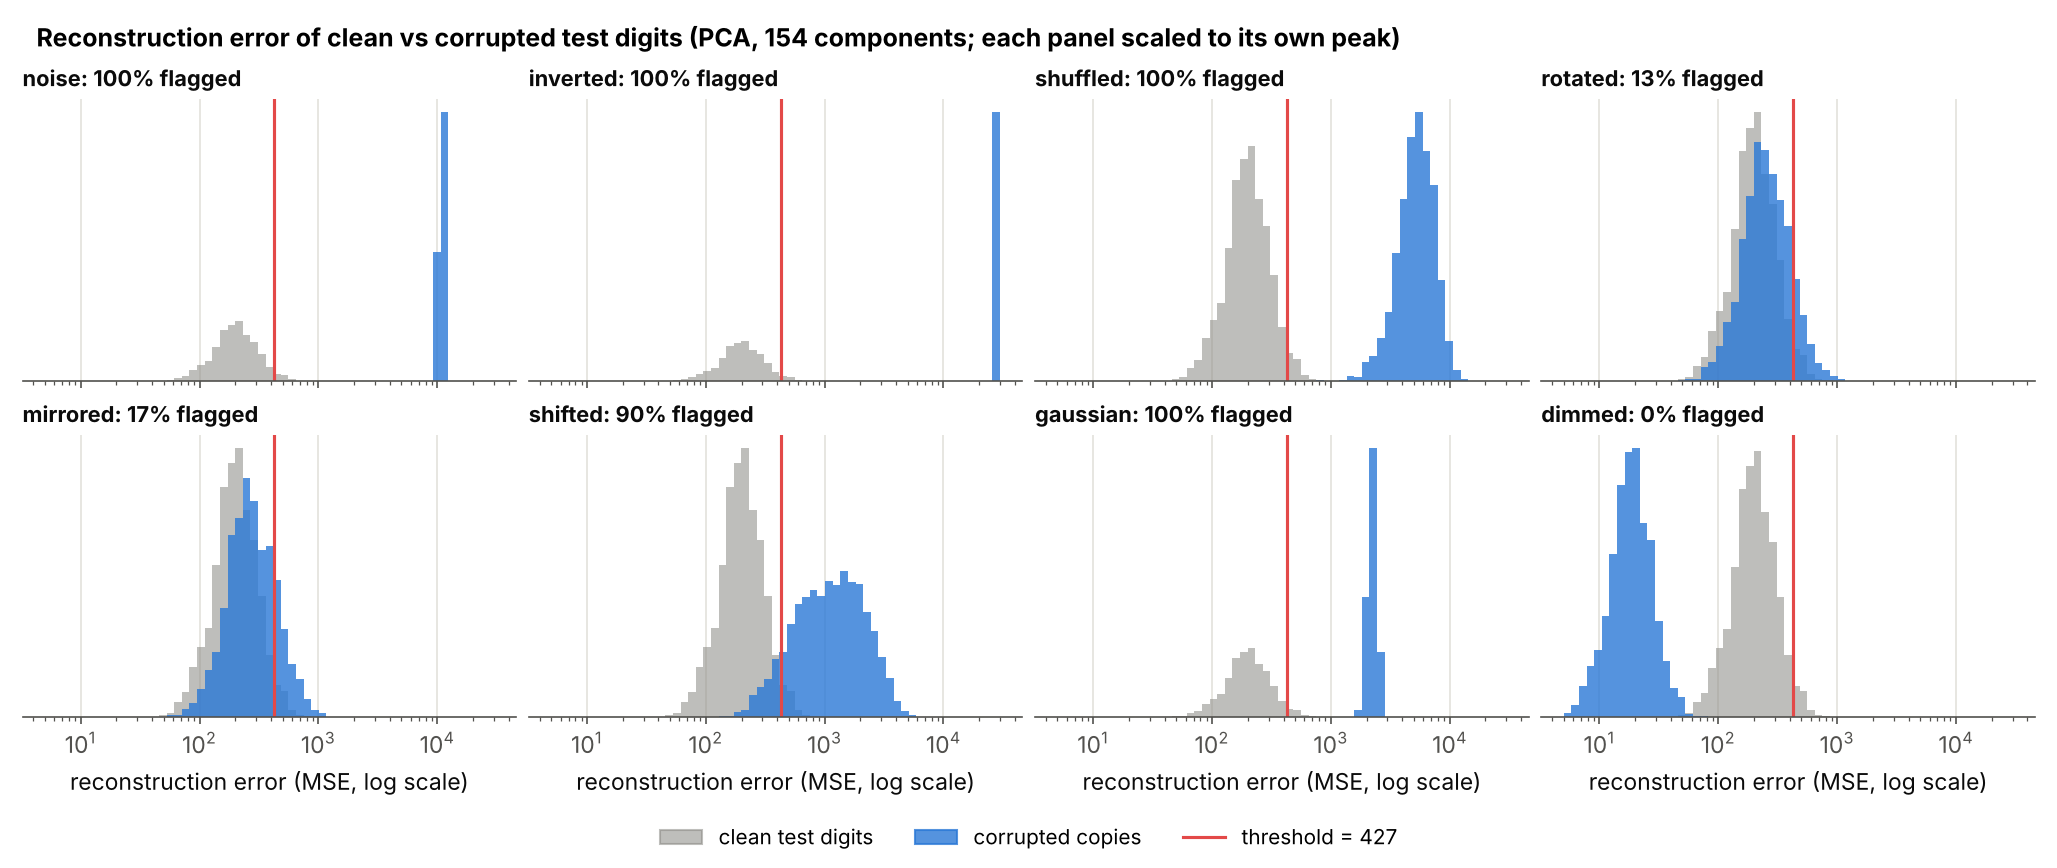

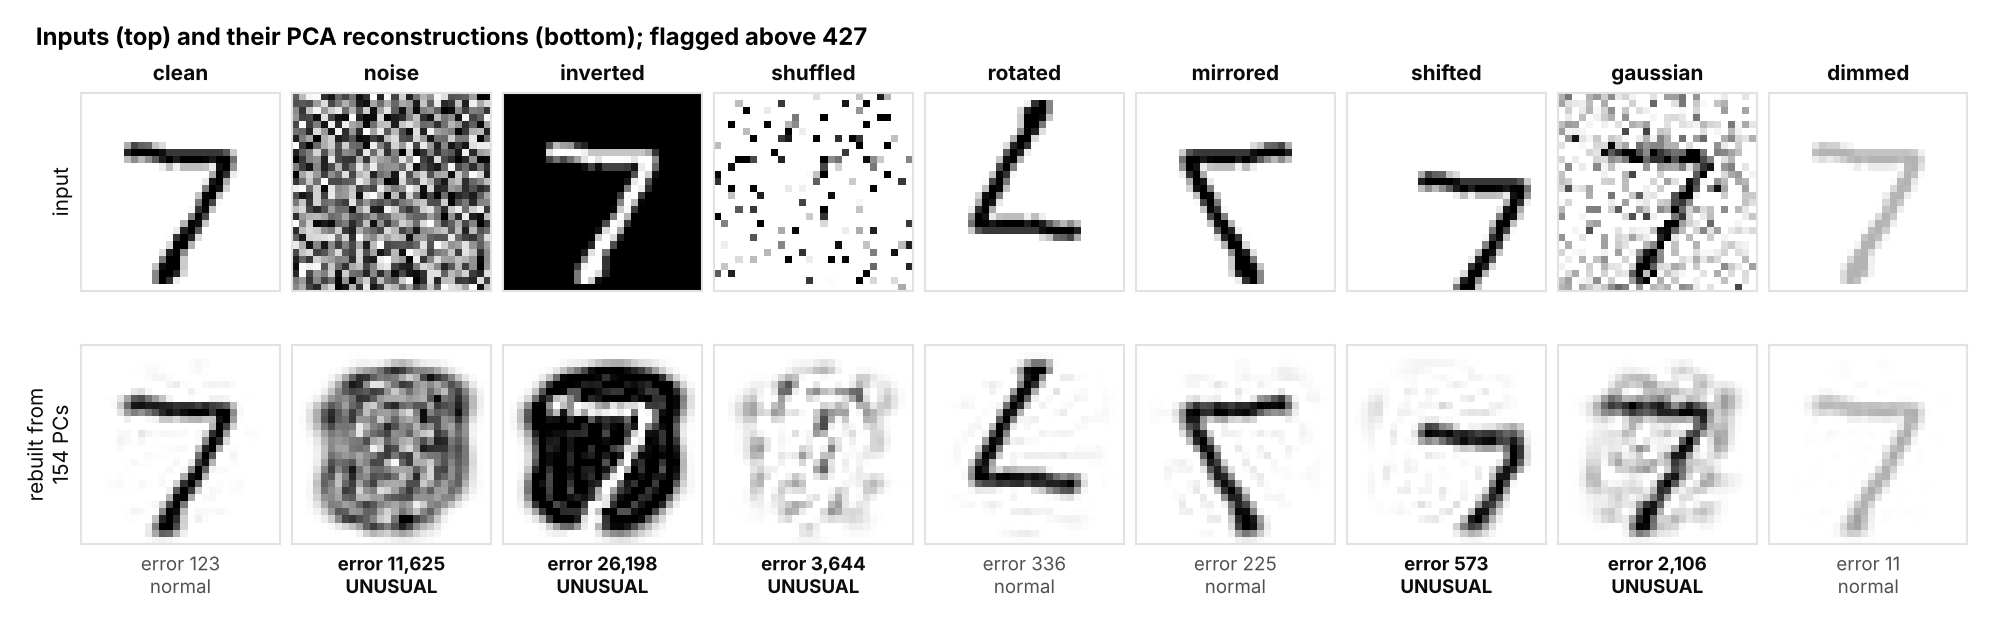

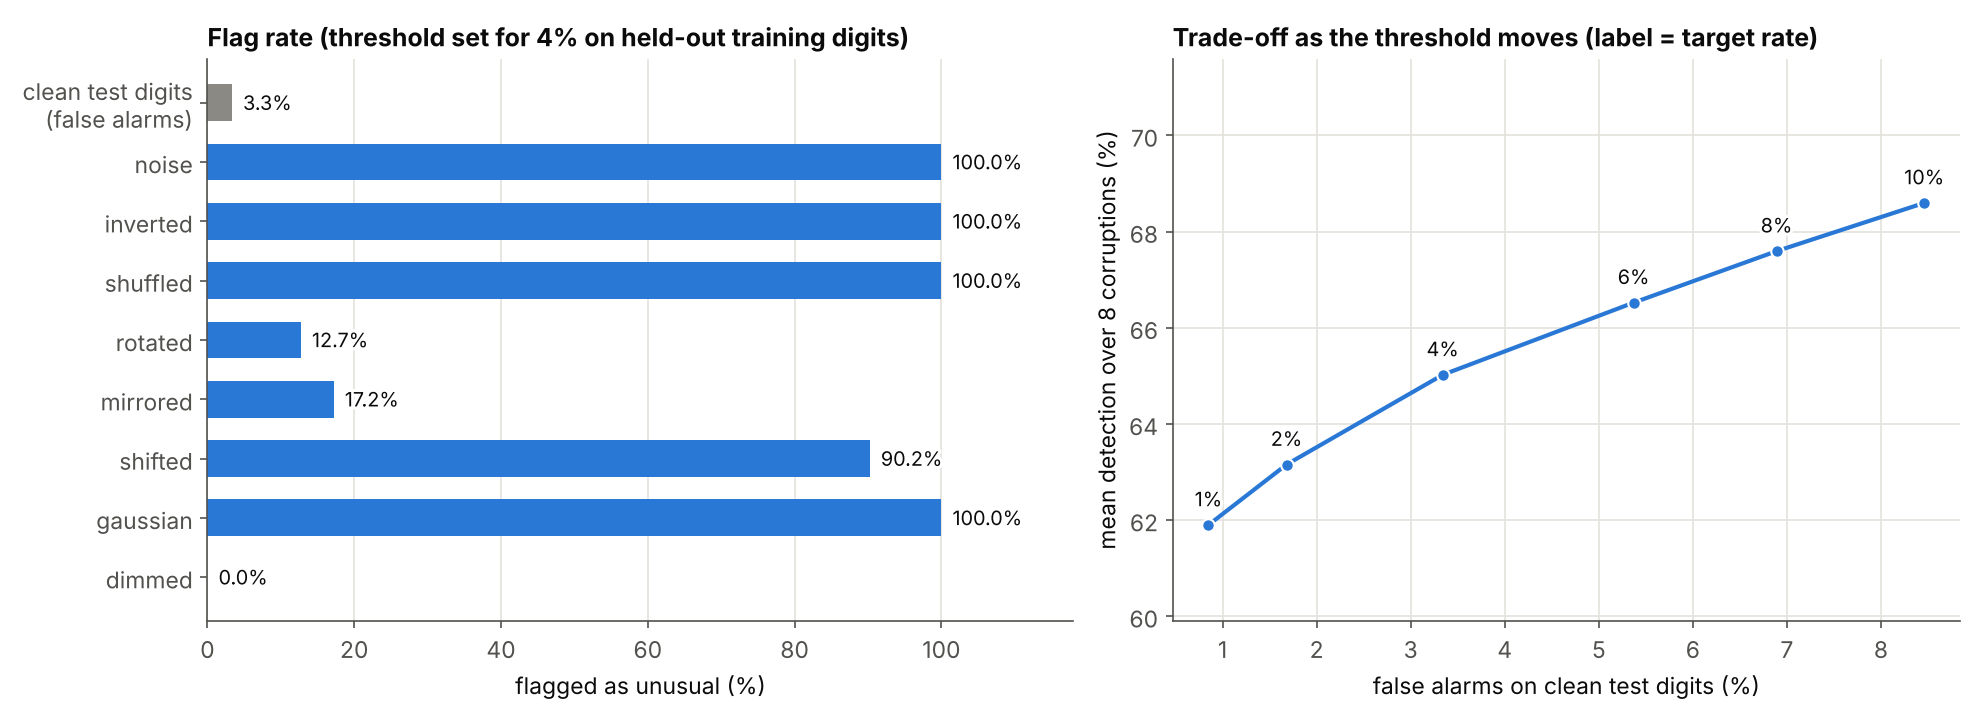

In [10]:
plots.error_histograms(f.errors, f.detector.threshold_, f.corruption_table, FIG / "f_error_histograms.png")
plots.corruption_examples(X_test, f.detector, FIG / "f_corruption_examples.png")
plots.detection_rates(f.corruption_table, f.threshold_sweep, FIG / "f_detection.png")
for name in ["f_error_histograms", "f_corruption_examples", "f_detection"]:
    display(Image(str(FIG / f"{name}.png"), width=950))

## Takeaways
* PCA makes the SVM 2 to 3 times faster to train and to predict (timings vary a little between runs). Its accuracy rises by 0.47 pp (paired 95% interval +0.31 to +0.63 pp). With the raw model's RBF bandwidth (`pca_same_gamma`), the gain shrinks to 0.12 pp (+0.01 to +0.23 pp). Most of the gain therefore comes from `gamma="scale"` choosing a different kernel width on the PCA features, not from the compression itself.
* PCA slows the Random Forest down and lowers its accuracy, as in the book's exercise 9. Whether compression helps depends on the model.
* The reconstruction-error flag catches every noise, inverted, shuffled and Gaussian-noise input, and 90% of shifted ones, at 3.3% false alarms. These are synthetic corruptions; no real out-of-distribution data is tested.
* Its blind spots: upside-down and mirrored digits still look like digits to PCA. Dimmed digits have a *smaller* error, because the error scales with the pixel intensities. These limits are reported, not hidden.